# Xav's Notebook: Winning Ticket for Convolution 6

In this notebook, we train the **Convolution-6** model on the **CIFAR10** dataset and study how **iterative pruning** can reveal a smaller subnetwork that still performs well. The goal is to identify a *“winning ticket”*, meaning a sparse subset of the original network’s weights that can be trained to reach comparable accuracy while using significantly fewer parameters. Concretely, we train the full network, prune a portion of weights according to a chosen criterion (e.g., magnitude), and then retrain the remaining masked network to evaluate whether the pruned subnetwork retains strong learning capacity.



In [1]:
# Let's import the useful libraries

import random
import numpy as np
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import torch.nn.functional as F

# Fix all random seeds
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# For full determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Import the best device available
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json, os

RESULTS_PATH = "/content/drive/MyDrive/conv6_results.json"

def load_results(path=RESULTS_PATH):
    if os.path.exists(path):
        with open(path, "r") as f:
            return json.load(f)
    return {}  # vide si rien

def save_results(results, path=RESULTS_PATH):
    tmp = path + ".tmp"
    with open(tmp, "w") as f:
        json.dump(results, f, indent=2)
    os.replace(tmp, path)  # écriture “safe”

In [4]:
import os, time, random
import numpy as np
import torch

def _to_cpu_state_dict(sd):
    return {k: v.detach().cpu() for k, v in sd.items()}

def _to_cpu_masks(masks):
    return {k: v.detach().cpu() for k, v in masks.items()}

def _rng_state():
    st = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.random.get_rng_state(),
    }
    if torch.cuda.is_available():
        st["torch_cuda"] = torch.cuda.get_rng_state_all()
    return st

def _set_rng_state(st):
    random.setstate(st["python"])
    np.random.set_state(st["numpy"])
    torch.random.set_rng_state(st["torch"])
    if torch.cuda.is_available() and "torch_cuda" in st:
        torch.cuda.set_rng_state_all(st["torch_cuda"])

def save_ckpt(path, payload: dict):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    tmp = path + ".tmp"
    payload = dict(payload)
    payload["timestamp"] = time.time()
    torch.save(payload, tmp)
    os.replace(tmp, path)

def load_ckpt(path, map_location="cpu"):
    return torch.load(path, map_location=map_location)

## Loading the Dataset and Define the Original model used in the paper : Conv6

In [5]:
# load the train dataset

test_dataset = torchvision.datasets.CIFAR10(
    root='./data/',
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor())


train_dataset = torchvision.datasets.CIFAR10(
    root='./data/',
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor())

# Split the dataset into 45k-5k samples for training-validation.
from torch.utils.data import random_split
train_dataset,  valid_dataset = random_split(
    train_dataset,
    lengths=[45000, 5000],
    generator=torch.Generator().manual_seed(42) # we use a generator to insure reproducibilty
)


100%|██████████| 170M/170M [00:02<00:00, 72.9MB/s]


In [6]:
import torch
import torch.nn as nn

class Conv6(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Conv-6: (64,64,pool) -> (128,128,pool) -> (256,256,pool)
        # All convs are 3x3 with padding=1 to preserve spatial size within each block.

        # CIFAR-10 input is (3, 32, 32)
        # After 3 pools: 32 -> 16 -> 8 -> 4, so final map is (256, 4, 4)
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=True),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # Flatten size is 256*4*4 = 4096 for CIFAR-10
        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.Linear(256 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Regarding the architecture of Conv6 here is some justifications :
  
-Using 3×3 matches the paper statement and gives a standard receptive-field growth.

-Using padding=1 ensures only pooling changes resolution; this matches the “64,64,pool …” style description (conv pairs keep size, pool halves it).

-Removing adaptive pooling and using flatten + FC matches the listed FC layers (256,256,10) setup.

-LazyLinear(256) avoids hardcoding the flatten dimension while keeping the paper’s FC widths

## Training the model with the parameters used in the Paper

In [7]:
# define the hyperparameters
BATCH_SIZE = 60
TEST_BATCH_SIZE = 512
LEARNING_RATE = 3e-4

In [8]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2)

train_dataloader_adam = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2)

valid_dataloader = DataLoader(
    dataset=valid_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2)

test_dataloader = DataLoader(
    dataset=test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,
    num_workers=2)

## Figure 1 : Pruning , Evaluation and Training with Masks

In [9]:
#Prunable parameters, mask application, and counting remaining weights

import copy
import torch
import torch.nn as nn

def iter_prunable_params(model: nn.Module):
    # prune conv/linear weights only (exclude biases and BN)
    for name, p in model.named_parameters():
        if p.requires_grad and name.endswith(".weight") and p.dim() >= 2:
            yield name, p

@torch.no_grad()
def apply_masks(model, masks):
    for name, p in model.named_parameters():
        if name in masks:
            p.mul_(masks[name])

def masks_keep_ratio(masks):
    kept = sum(int(m.sum().item()) for m in masks.values())
    total = sum(m.numel() for m in masks.values())
    return kept / total


In [10]:
#Random mask (global)
@torch.no_grad()
def make_global_random_masks(model, keep_ratio: float, seed: int):
    params = list(iter_prunable_params(model))
    device = params[0][1].device
    total = sum(p.numel() for _, p in params)
    k = max(1, int(keep_ratio * total))

    g = torch.Generator(device=device).manual_seed(seed)
    idx = torch.randperm(total, generator=g, device=device)[:k]

    masks = {}
    offset = 0
    for name, p in params:
        n = p.numel()
        mask_flat = torch.zeros(n, device=device, dtype=p.dtype)
        local = idx[(idx >= offset) & (idx < offset + n)] - offset
        mask_flat[local] = 1.0
        masks[name] = mask_flat.view_as(p)
        offset += n
    return masks

In [11]:
# Magnitude pruning “by group” (conv vs fc) per round (paper-style)

def is_conv_weight(name, param):
    return param.dim() == 4  # Conv2d weight: (out,in,k,k)

def is_fc_weight(name, param):
    return param.dim() == 2  # Linear weight: (out,in)

@torch.no_grad()
def prune_by_magnitude_inplace(model, masks, conv_prune_frac=0.15, fc_prune_frac=0.20):
    # prune additional fraction among CURRENTLY-KEPT weights
    for name, p in iter_prunable_params(model):
        w = p.detach()
        m = masks[name].detach()

        # consider only currently kept weights
        kept_vals = w.abs()[m.bool()]
        if kept_vals.numel() == 0:
            continue

        prune_frac = conv_prune_frac if is_conv_weight(name, p) else (fc_prune_frac if is_fc_weight(name, p) else 0.0)
        if prune_frac <= 0:
            continue

        k_prune = int(prune_frac * kept_vals.numel())
        if k_prune < 1:
            continue

        # threshold: prune the smallest magnitudes among kept weights
        thresh = torch.kthvalue(kept_vals, k_prune).values
        to_prune = (w.abs() <= thresh) & (m > 0)

        new_m = m.clone()
        new_m[to_prune] = 0.0
        masks[name] = new_m.to(p.dtype)

    # enforce immediately
    apply_masks(model, masks)
    return masks

In [12]:
# Training that returns “early-stop iteration” = argmin val loss

@torch.no_grad()
def evaluate_model(model, loader, device, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_correct += (logits.argmax(1) == y).sum().item()
        total += bs
    return total_loss / total, total_correct / total

def train_masked_and_get_best_iter(model, train_loader, val_loader, test_loader, device,
                                  optimizer, max_steps, masks=None):
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    if masks is not None:
        apply_masks(model, masks)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    best_iter = 0

    step = 0
    model.train()
    train_iter = iter(train_loader)

    while step < max_steps:
      if(step % 1000 == 0) :
       print(f"  step {step}/{max_steps} ...")
      try:
            x, y = next(train_iter)
      except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

      x, y = x.to(device), y.to(device)
      optimizer.zero_grad(set_to_none=True)
      logits = model(x)
      loss = criterion(logits, y)
      loss.backward()
      optimizer.step()
      if masks is not None:
          apply_masks(model, masks)

      step += 1

        # validate occasionally (to approximate "min val loss iteration")
        # pick something like every 100 steps
      if step % 100 == 0 or step == max_steps:
          vloss, _ = evaluate_model(model, val_loader, device, criterion)
          if vloss < best_val_loss:
                best_val_loss = vloss
                best_iter = step
                best_state = copy.deepcopy(model.state_dict())

    # test accuracy at the best iteration
    model.load_state_dict(best_state)
    _, test_acc = evaluate_model(model, test_loader, device, nn.CrossEntropyLoss())
    return best_iter, test_acc

### produce the two curves (random vs winning ticket)

In [13]:
def run_random_curve_resume(
    model_ctor, keep_ratios, trials,
    train_loader, val_loader, test_loader,
    device, max_steps, lr,
    results_path=RESULTS_PATH,
    resume: bool = True,          # ignore old file if False
    overwrite: bool = False,      # wipe "random" section if True
    seed_base: int = 1000
):
    if resume:
        results = load_results(results_path)
    else:
        results = {}  # start fresh in memory (ignores existing saved results)

    results.setdefault("random", {})

    if overwrite:
        results["random"] = {}    # wipe previous random results for a clean run


    for kr in keep_ratios:

      if kr > 0.4 :
        max_steps = max_steps
      elif kr < 0.4 and kr > 0.15 :
         max_steps = 15000
         trials = 6
      elif kr < 0.15 :
         max_steps = 25000
         trials = 6

      for t in range(trials):
            key = f"kr={kr:.6f}_trial={t}"

            if resume and key in results["random"]:
                print(f"[SKIP] random {key} (déjà calculé)")
                continue

            print(f"[RUN] random keep_ratio={kr:.3f} trial {t+1}/{trials}")
            model = model_ctor().to(device)
            masks = make_global_random_masks(model, keep_ratio=kr, seed=seed_base + t)
            opt = torch.optim.Adam(model.parameters(), lr=lr)

            best_iter, test_acc = train_masked_and_get_best_iter(
                model, train_loader, val_loader, test_loader, device,
                optimizer=opt, max_steps=max_steps, masks=masks
            )

            results["random"][key] = {
                "keep_ratio": float(kr),
                "trial": int(t),
                "best_iter": int(best_iter),
                "test_acc": float(test_acc),
                "max_steps": int(max_steps),
                "lr": float(lr),
                "seed": int(seed_base + t),
            }
            save_results(results, results_path)

    return results

In [14]:
def run_ticket_curve_resume(
    model_ctor, keep_ratios, trials,
    train_loader, val_loader, test_loader,
    device, max_steps, lr, conv_prune=0.15, fc_prune=0.20,
    results_path=RESULTS_PATH,
    resume: bool = True,          # <-- add this
    overwrite: bool = False      # <-- optionally wipe "ticket" section
):
    if resume:
        results = load_results(results_path)
    else:
        results = {}  # ignore previous file entirely

    results.setdefault("ticket", {})

    if overwrite:
        results["ticket"] = {}    # wipe ticket results for a clean run

    for kr_target in keep_ratios:

       if kr_target > 0.4 :
        max_steps = max_steps
       elif kr_target < 0.4 and kr_target > 0.15 :
         max_steps = 15000
       elif kr_target < 0.15 :
        max_steps = 25000


       for t in range(trials):
            key = f"kr={kr_target:.6f}_trial={t}"

            if resume and key in results["ticket"]:
                print(f"[SKIP] ticket {key} (déjà calculé)")
                continue

            print(f"[RUN] ticket keep_ratio={kr_target:.3f} trial {t+1}/{trials}")

            model0 = model_ctor().to(device)
            init_state = {k: v.detach().clone() for k, v in model0.state_dict().items()}
            masks = {name: torch.ones_like(p) for name, p in iter_prunable_params(model0)}

            current_keep = masks_keep_ratio(masks)
            model = model_ctor().to(device)

            rounds = 0
            while current_keep > kr_target:
                rounds += 1
                print(f"round number {rounds} ")
                model.load_state_dict(init_state)
                apply_masks(model, masks)

                opt = torch.optim.Adam(model.parameters(), lr=lr)
                _best_iter, _test_acc = train_masked_and_get_best_iter(
                    model, train_loader, val_loader, test_loader, device,
                    optimizer=opt, max_steps=max_steps, masks=masks
                )

                masks = prune_by_magnitude_inplace(model, masks, conv_prune, fc_prune)
                current_keep = masks_keep_ratio(masks)

                if current_keep <= kr_target:
                    break

            model.load_state_dict(init_state)
            apply_masks(model, masks)
            opt = torch.optim.Adam(model.parameters(), lr=lr)
            best_iter, test_acc = train_masked_and_get_best_iter(
                model, train_loader, val_loader, test_loader, device,
                optimizer=opt, max_steps=max_steps, masks=masks
            )

            results["ticket"][key] = {
                "keep_ratio": float(kr_target),
                "trial": int(t),
                "rounds": int(rounds),
                "best_iter": int(best_iter),
                "test_acc": float(test_acc),
                "max_steps": int(max_steps),
                "lr": float(lr),
                "conv_prune": float(conv_prune),
                "fc_prune": float(fc_prune),
            }

            save_results(results, results_path)

    return results

In [15]:
# Plotting

import matplotlib.pyplot as plt
import numpy as np

def plot_figure(random_res, ticket_res):
    # This function plots the random and winning ticket curves.
    # random_res/ticket_res are lists of (kr, iters_tensor, accs_tensor)
    x = np.array([kr*100 for kr,_,_ in random_res])

    # left: best_iter (K)
    plt.figure()
    for label, res, ls in [("random", random_res, "--"), ("Conv-6 ticket", ticket_res, "-")]:
        mean_iters = np.array([r[1].mean().item() for r in res]) / 1000.0
        std_iters  = np.array([r[1].std(unbiased=False).item() for r in res]) / 1000.0
        plt.errorbar(x, mean_iters, yerr=std_iters, linestyle=ls, marker="o", capsize=3, label=label)
    plt.xlabel("Percent of Weights Remaining")
    plt.ylabel("Iteration of Minimum Validation Loss (K)")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.show()

    # right: test accuracy at that iteration
    plt.figure()
    for label, res, ls in [("random", random_res, "--"), ("Conv-6 ticket", ticket_res, "-")]:
        mean_acc = np.array([r[2].mean().item() for r in res])
        std_acc  = np.array([r[2].std(unbiased=False).item() for r in res])
        plt.errorbar(x, mean_acc, yerr=std_acc, linestyle=ls, marker="o", capsize=3, label=label)
    plt.xlabel("Percent of Weights Remaining")
    plt.ylabel("Test Accuracy at Best-Validation Iteration")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.show()

In [16]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [17]:
%%time
# =========================
# 2) Experiment settings
# =========================
model_ctor = lambda: Conv6()

keep_ratios = [1.0, 0.412, 0.170, 0.071, 0.030, 0.013]  # x-axis points (weights remaining)

max_steps = 8000    # paper: 30K iterations

random_trials = 5   # dashed lines in caption
ticket_trials = 2    # solid lines in caption

# pruning per round for Conv-6 (from table): conv15% fc20%
conv_prune_frac = 0.15
fc_prune_frac   = 0.20

# =========================
# 3) Run random subnetworks (dashed)
# =========================
set_seed(123)
random_res = run_random_curve_resume(
    model_ctor=model_ctor,
    keep_ratios=keep_ratios,
    trials=random_trials,
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    test_loader=test_dataloader,
    device=device,
    max_steps=max_steps,
    lr=LEARNING_RATE,
)

[SKIP] random kr=1.000000_trial=0 (déjà calculé)
[SKIP] random kr=1.000000_trial=1 (déjà calculé)
[SKIP] random kr=1.000000_trial=2 (déjà calculé)
[SKIP] random kr=1.000000_trial=3 (déjà calculé)
[SKIP] random kr=1.000000_trial=4 (déjà calculé)
[SKIP] random kr=0.412000_trial=0 (déjà calculé)
[SKIP] random kr=0.412000_trial=1 (déjà calculé)
[SKIP] random kr=0.412000_trial=2 (déjà calculé)
[SKIP] random kr=0.412000_trial=3 (déjà calculé)
[SKIP] random kr=0.412000_trial=4 (déjà calculé)
[SKIP] random kr=0.170000_trial=0 (déjà calculé)
[SKIP] random kr=0.170000_trial=1 (déjà calculé)
[SKIP] random kr=0.170000_trial=2 (déjà calculé)
[SKIP] random kr=0.170000_trial=3 (déjà calculé)
[SKIP] random kr=0.170000_trial=4 (déjà calculé)
[SKIP] random kr=0.170000_trial=5 (déjà calculé)
[SKIP] random kr=0.071000_trial=0 (déjà calculé)
[SKIP] random kr=0.071000_trial=1 (déjà calculé)
[SKIP] random kr=0.071000_trial=2 (déjà calculé)
[SKIP] random kr=0.071000_trial=3 (déjà calculé)
[SKIP] random kr=0.0

In [18]:
%%time
# =========================
# 4) Run winning tickets (solid)
# =========================
set_seed(456)
ticket_res = run_ticket_curve_resume(
    model_ctor=model_ctor,           # e.g. lambda: Conv6()
    keep_ratios=keep_ratios,         # list of sparsity targets
    trials=ticket_trials,            # number of trials per keep_ratio (except <0.15 -> forced to 2)
    train_loader=train_dataloader,
    val_loader=valid_dataloader,
    test_loader=test_dataloader,
    device=device,                   # "cuda" or "cpu"
    max_steps=max_steps,             # unused as-is (local_max_steps overrides inside)
    lr=LEARNING_RATE,
    conv_prune=conv_prune_frac,
    fc_prune=fc_prune_frac,
)


[SKIP] ticket kr=1.000000_trial=0 (déjà calculé)
[SKIP] ticket kr=1.000000_trial=1 (déjà calculé)
[SKIP] ticket kr=0.412000_trial=0 (déjà calculé)
[SKIP] ticket kr=0.412000_trial=1 (déjà calculé)
[SKIP] ticket kr=0.170000_trial=0 (déjà calculé)
[SKIP] ticket kr=0.170000_trial=1 (déjà calculé)
[SKIP] ticket kr=0.071000_trial=0 (déjà calculé)
[SKIP] ticket kr=0.071000_trial=1 (déjà calculé)
[SKIP] ticket kr=0.030000_trial=0 (déjà calculé)
[SKIP] ticket kr=0.030000_trial=1 (déjà calculé)
[SKIP] ticket kr=0.013000_trial=0 (déjà calculé)
[SKIP] ticket kr=0.013000_trial=1 (déjà calculé)
CPU times: user 552 µs, sys: 1.85 ms, total: 2.41 ms
Wall time: 4.1 ms


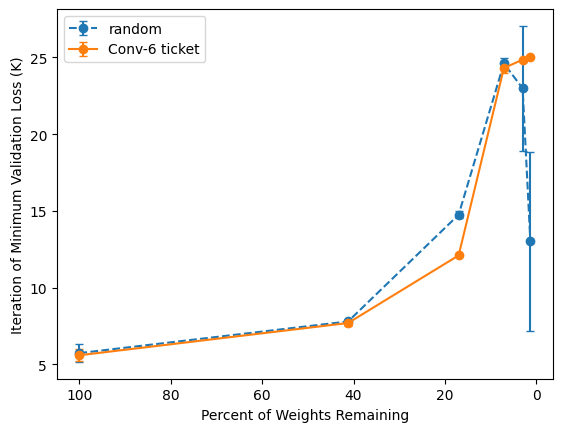

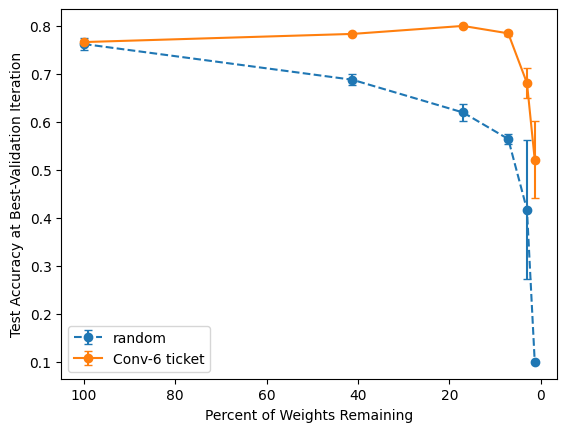

In [19]:
def process_results_for_plot(raw_results_dict):
    processed = []
    grouped_by_kr = {}
    for key, val in raw_results_dict.items():
        kr = val["keep_ratio"]
        if kr not in grouped_by_kr:
            grouped_by_kr[kr] = {"best_iters": [], "test_accs": []}
        grouped_by_kr[kr]["best_iters"].append(val["best_iter"])
        grouped_by_kr[kr]["test_accs"].append(val["test_acc"])

    for kr in sorted(grouped_by_kr.keys(), reverse=True):
        iters = torch.tensor(grouped_by_kr[kr]["best_iters"], dtype=torch.float32)
        accs = torch.tensor(grouped_by_kr[kr]["test_accs"], dtype=torch.float32)
        processed.append((kr, iters, accs))
    return processed

# =========================
# 5) Plot Figure 1 (two panels)
# =========================

# Process the raw results dictionaries into the format expected by plot_figure
processed_random_res = process_results_for_plot(random_res["random"])
processed_ticket_res = process_results_for_plot(ticket_res["ticket"])

plot_figure(processed_random_res, processed_ticket_res)


In [ ]:
# =========================
# 6) Optional: print raw results
# =========================
print("RANDOM:")
for kr, iters, accs in processed_random_res:
    print(f"keep={kr:.3f} | best_iter mean={iters.mean():.1f} std={iters.std(unbiased=False):.1f} | "
          f"test_acc mean={accs.mean():.4f} std={accs.std(unbiased=False):.4f}")

print("\nTICKET:")
for kr, iters, accs in processed_ticket_res:
    print(f"keep={kr:.3f} | best_iter mean={iters.mean():.1f} std={iters.std(unbiased=False):.1f} | "
          f"test_acc mean={accs.mean():.4f} std={accs.std(unbiased=False):.4f}")